# Person 3 Exploration

This notebook verifies the P2 handoff artifacts and demonstrates the execution of Graphs 10, 11, and 6.

In [1]:
import numpy as np
import json
from pathlib import Path
from IPython.display import Image, display

ROOT = Path("..")
ARTIFACTS = ROOT / "artifacts"

print("Artifacts check:")
print("corr_denoised.npy shape:", np.load(ARTIFACTS / "corr_denoised.npy").shape)
print("threshold.json:", json.loads((ARTIFACTS / "threshold.json").read_text())['chosen_threshold'])

Artifacts check:
corr_denoised.npy shape: (60, 60)
threshold.json: 0.22


## Graph 10: Communities vs Three Null Models

  item graph: 60 nodes, 131 edges at |r| > 0.22
  Leiden: 15 communities, Q = 0.4721
  NMI (community vs topic block) = 0.2006
  computing null distributions for item network...
  permutation null: 200 replicates loaded
    permutation replicate 50/200
    permutation replicate 100/200
    permutation replicate 150/200
    permutation replicate 200/200
  rewiring null: 200 replicates...
  ER null: 200 replicates...

  null                     mean       sd        z        p
  permutation             0.624    0.046    -3.32    1.000
  rewiring                0.326    0.014    10.39    0.005
  ER                      0.407    0.017     3.91    0.005

  wrote /home/dev/Desktop/m26/dpcn/a1/dpcn_a1_opinion_network/figures/person3/graph_10_communities_nulls.png / .pdf
  wrote artifacts/graph10_communities.json


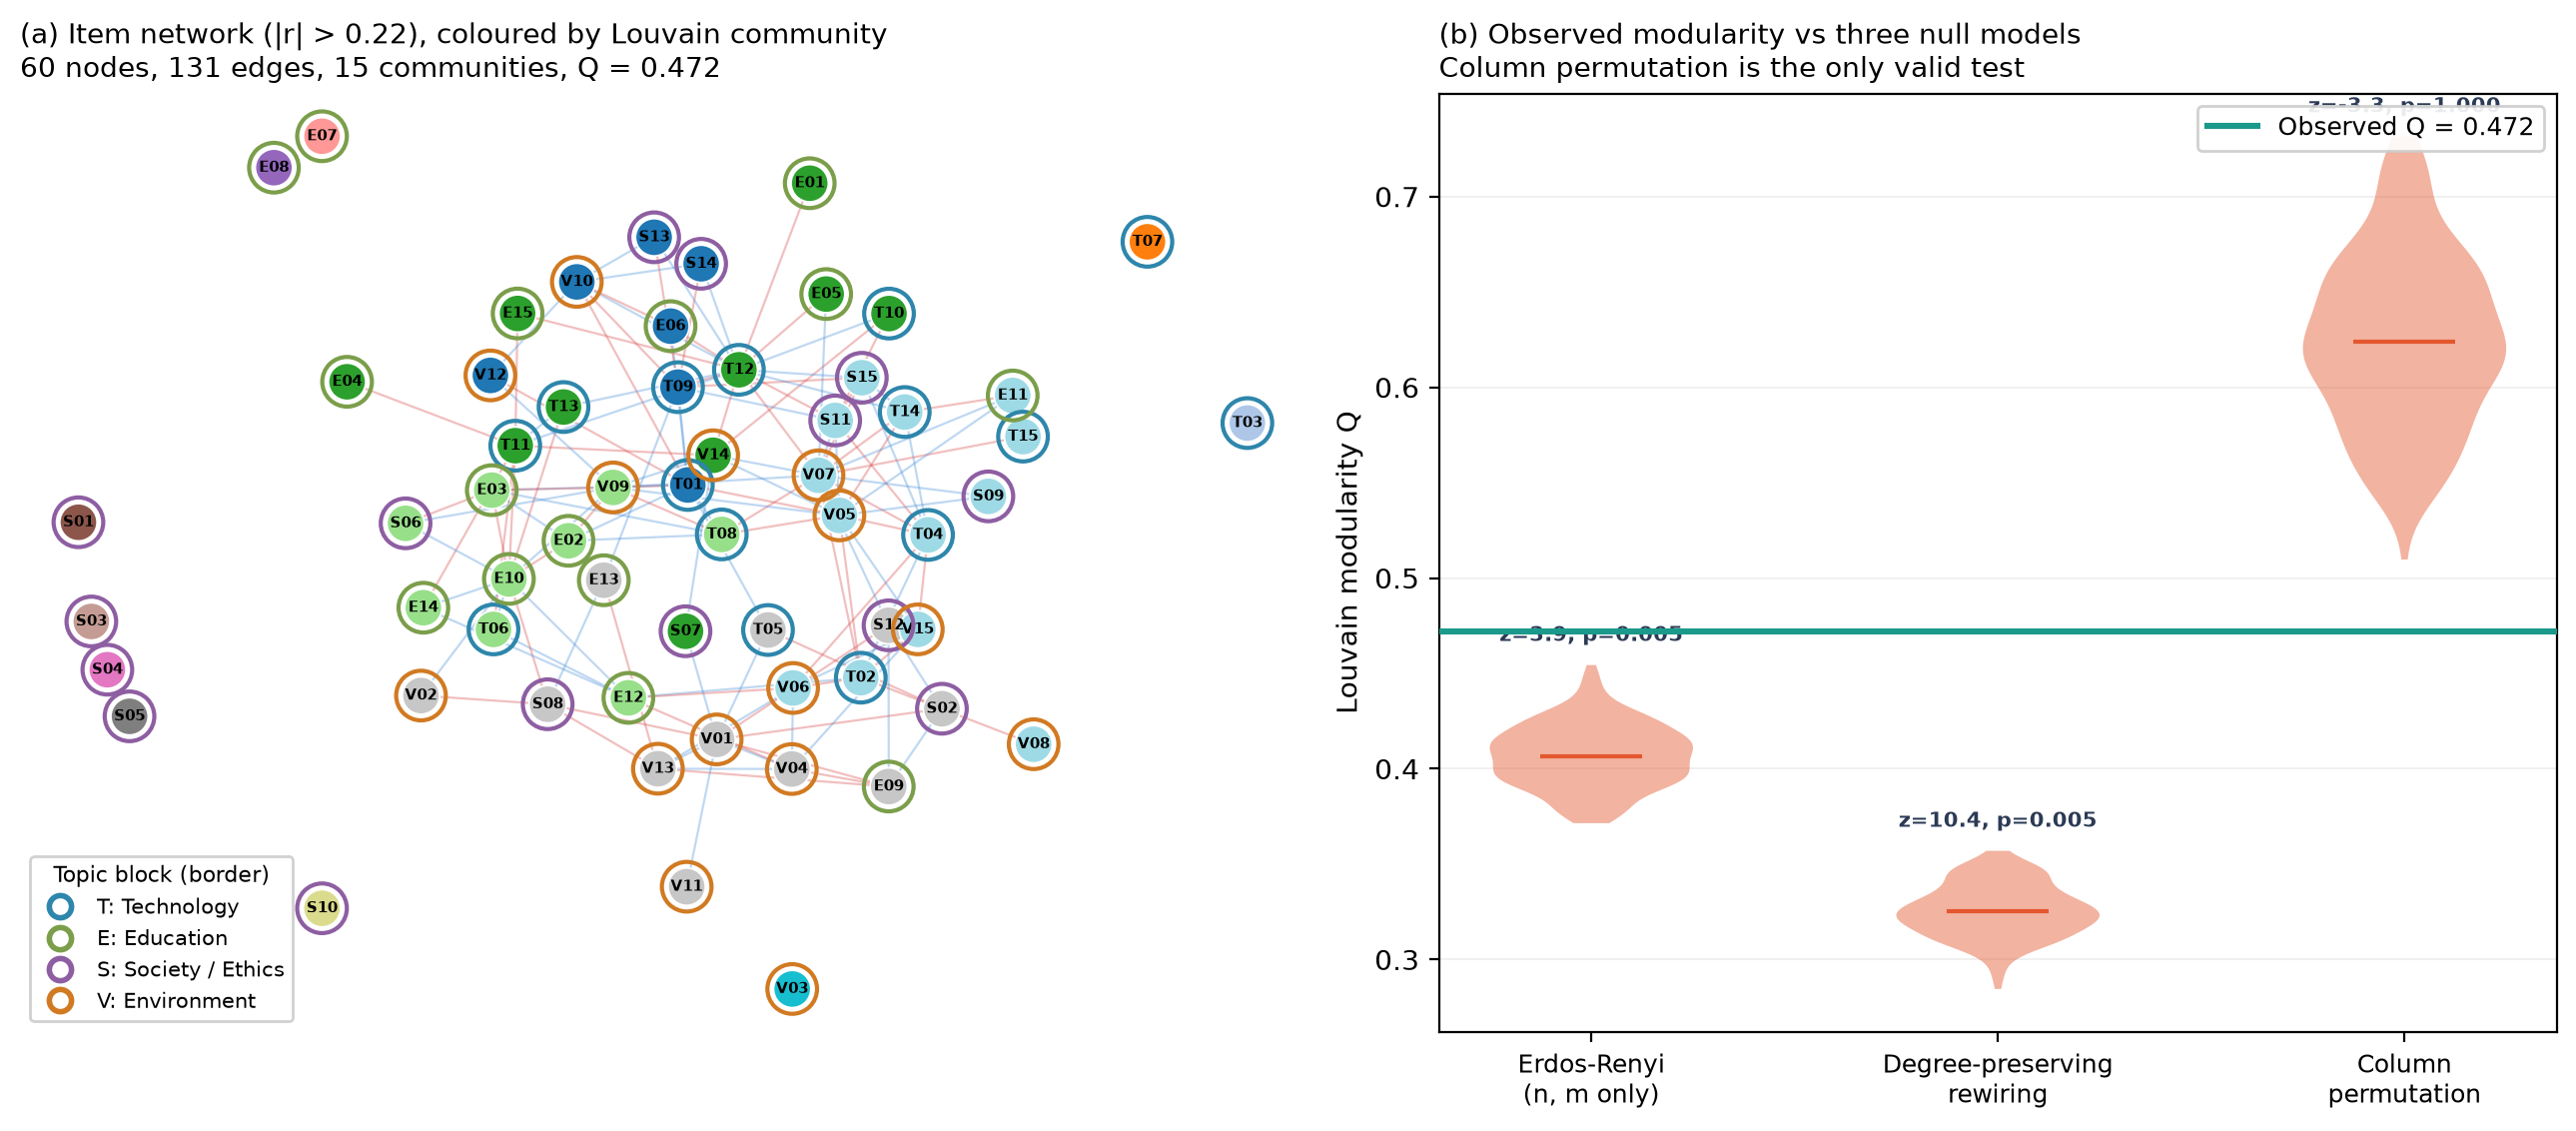

In [2]:
import sys; sys.path.insert(0, str(ROOT.absolute()))
from src.person3.graph_10 import run as run_g10
stats_g10 = run_g10()
display(Image(filename=str(ROOT / "figures/person3/graph_10_communities_nulls.png")))

## Graph 11: Structural Balance

  computing structural balance across threshold sweep...
    threshold 0.14: 1359 triads, balanced = 0.988
    threshold 0.24: 33 triads, balanced = 1.000
    threshold 0.34: 1 triads, balanced = 1.000
    threshold 0.44: 0 triads, balanced = nan

  GRAPH 11 STRUCTURAL BALANCE
   threshold   triads   balanced  null mean        z
        0.05    12960      0.787      0.500    65.59
        0.06     9854      0.830      0.500    66.12
        0.07     7816      0.862      0.500    65.88
        0.08     6211      0.891      0.500    58.90
        0.09     4844      0.922      0.500    62.10
        0.10     3927      0.940      0.500    54.32
        0.11     3026      0.959      0.500    51.47
        0.12     2249      0.972      0.500    45.15
        0.13     1777      0.984      0.500    40.55
        0.14     1359      0.988      0.500    36.45
        0.15      983      0.991      0.500    33.61
        0.16      771      0.995      0.501    28.22
        0.17      581      0.997 

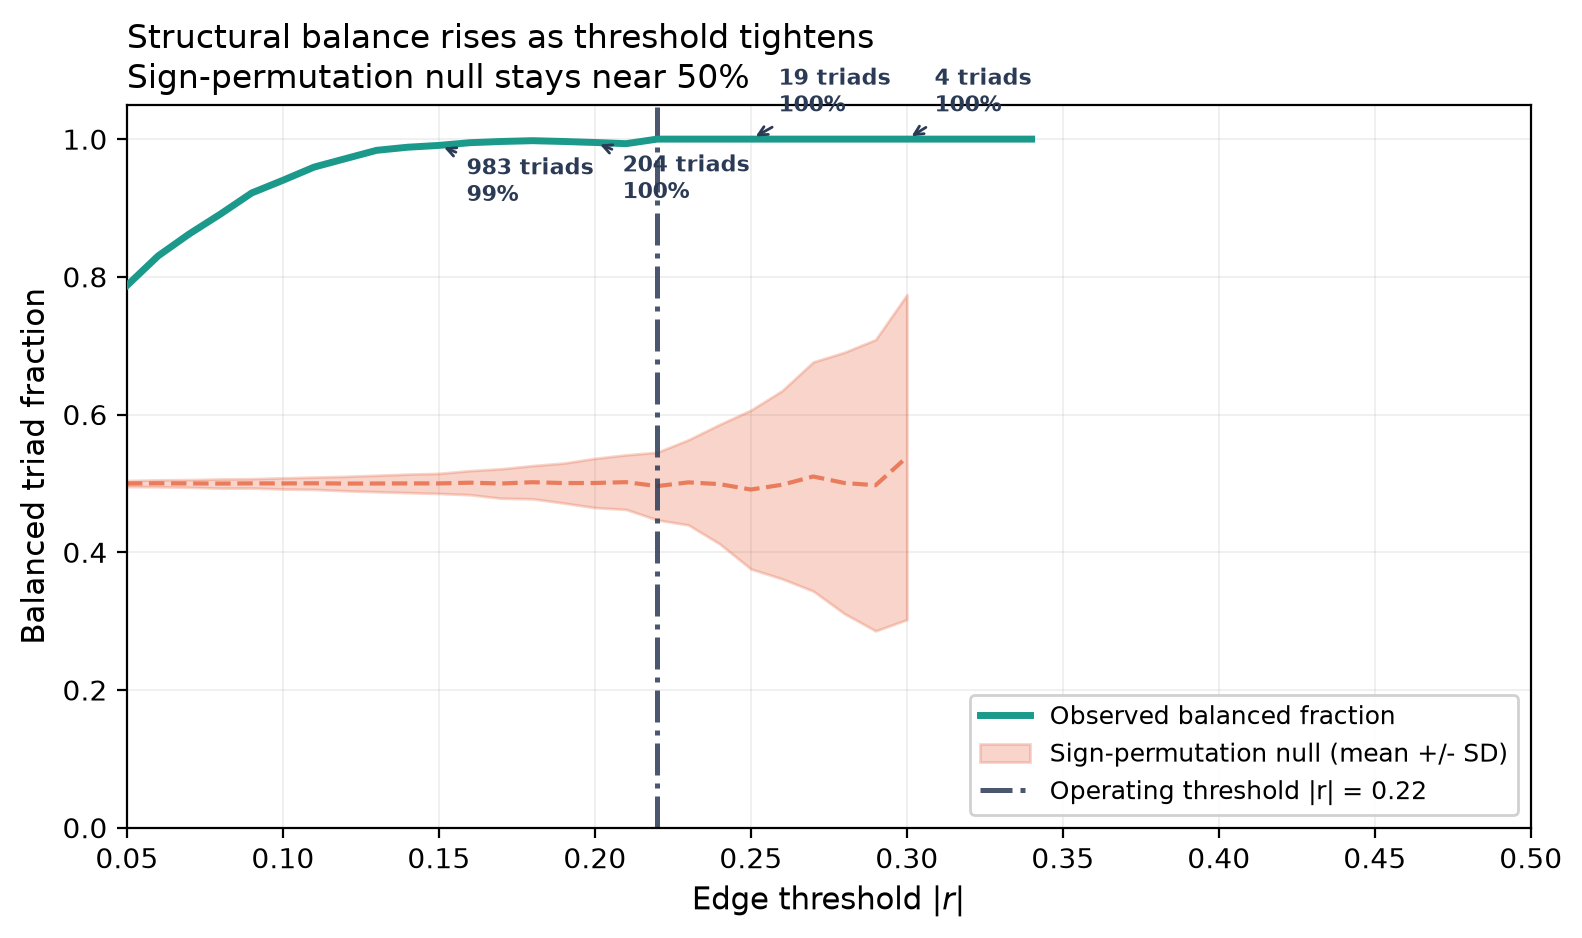

In [3]:
from src.person3.graph_11 import run as run_g11
stats_g11 = run_g11()
display(Image(filename=str(ROOT / "figures/person3/graph_11_structural_balance.png")))

## Graph 6: Reordered Heatmap

  denoised matrix: (60, 60)
  60 items, 15 communities

  wrote /home/dev/Desktop/m26/dpcn/a1/dpcn_a1_opinion_network/figures/person3/graph_6_reordered_heatmap.png / .pdf


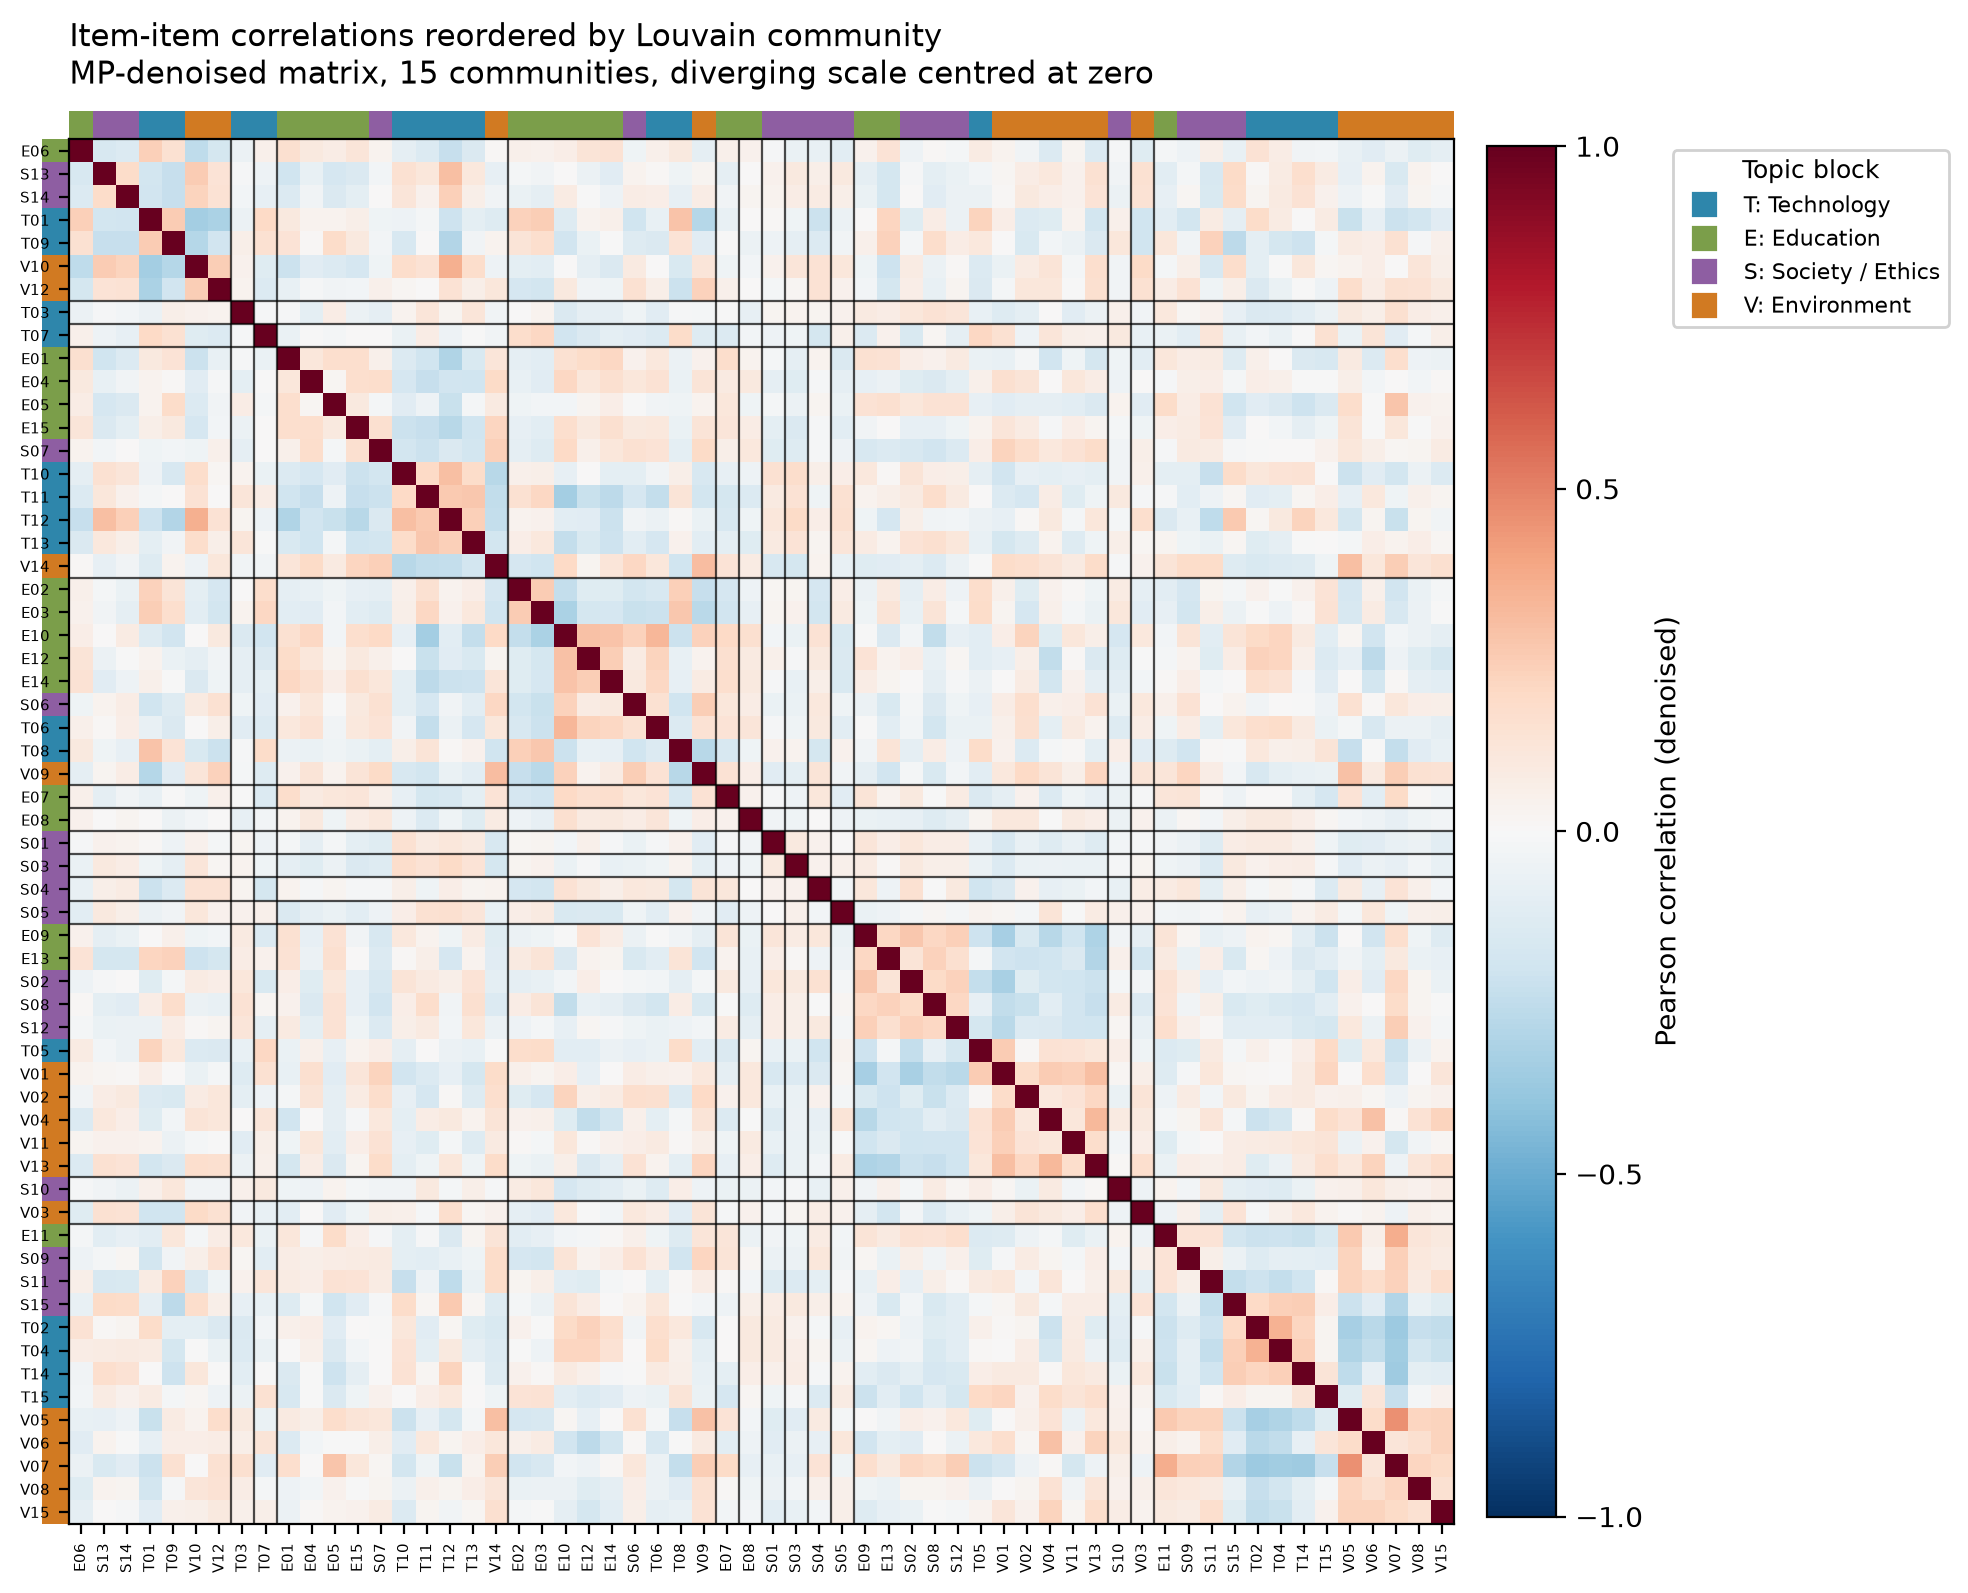

In [4]:
from src.person3.graph_6 import run as run_g6
stats_g6 = run_g6()
display(Image(filename=str(ROOT / "figures/person3/graph_6_reordered_heatmap.png")))

## Report Numbers
Extracting numbers needed for the report text.

In [5]:
print("\n--- Key Report Numbers ---")
print(f"Observed Modularity: {stats_g10['Q_observed']:.3f}")
print(f"NMI (Communities vs Topic Blocks): {stats_g10['nmi_vs_topic_blocks']:.3f}")
print("\nNull Z-Scores:")
for k, v in stats_g10['nulls'].items():
    print(f"  {k}: z = {v['z']:.2f}")
print("\nStructural Balance:")
for r in stats_g11['sweep']:
    if r['threshold'] in (0.15, 0.20, 0.25, 0.30):
        print(f"  |r| > {r['threshold']:.2f}: {r['balanced_fraction']*100:.0f}% ({r['total_triads']} triads)")



--- Key Report Numbers ---
Observed Modularity: 0.472
NMI (Communities vs Topic Blocks): 0.201

Null Z-Scores:
  permutation: z = -3.32
  rewiring: z = 10.39
  er: z = 3.91

Structural Balance:
  |r| > 0.20: 100% (204 triads)
